# BIG DATA

In [77]:
sparko=spark.sparkContext#to show context
contextInfo = f"""
Appname   --> {sparko.appName}
Version   --> {sparko.version}
SparkUser --> {sparko.sparkUser()}
"""
print(contextInfo)



Appname   --> myFirstTxt
Version   --> 3.5.3
SparkUser --> yusufsertkaya



### Imports


In [78]:
import pyspark
import os
import findspark
from pyspark.sql import SparkSession
from pyspark.conf import SparkConf
import matplotlib.pyplot as plt
import re
from wordcloud import WordCloud
import warnings
import pandas as pd
import numpy as np
from pyspark import SparkContext




In [79]:
spark=SparkSession.builder.appName("myFirstTxt").getOrCreate()

24/11/30 18:12:09 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [80]:
df=spark.read.csv("leipzig124MB.txt")

In [81]:
df.show(5)#first 5 rows

+--------------------+
|                 _c0|
+--------------------+
|A rebel statement...|
|Authorities last ...|
|At the first Pan ...|
|          Mr. Neigum|
|                This|
+--------------------+
only showing top 5 rows



In [82]:
pddf=df.pandas_api()
# Displaying 
pddf.iloc[:5, :5]  # Selects 5 rows and only the first 5 columns but we have 1 column sooo 🥲


,_c0
0,A rebel statement sent to Lisbon from Jamba sa...
1,Authorities last week issued a vacate order fo...
2,At the first Pan Am bankruptcy hearing
3,Mr. Neigum
4,This


In [70]:
rdd = sparko.textFile('./leipzig124MB.txt')

In [83]:
contractions = {
    r"'m": " am",
    r"’m": " am",
    r"'s": " is",
    r"’s": " is",
    r"isn't": "is not",
    r"Isn't": "Is not",
    r"'re": " are",
    r"’re": " are",
    r"aren't": "are not",
    r"'ll": " will",
    r"shouldn't": "should not",
    r"Shouldn't": "Should not",
    r"Haven't": "Have not",
    r"'d": " would",
    r"’d": " would",
    r"wouldn't": "would not",
    r"Wouldn't": "Would not",
    r"don't": "do not",
    r"Don't": "Do not",
    r"doesn't": "does not",
    r"Doesn't": "Does not",
    r"didn't": "did not",
    r"could've": "could have",
    r"Could've": "Could have",
    r"couldn't": "could not",
    r"Couldn't": "Could not",
    r"might've": "might have",
    r"Might've": "Might have",
    r"mustn't": "must not",
    r"Mustn't": "Must not",
    r"Aren't": "Are not",
    r"'ve": " have",
    r"’ve": " have",
    r"haven't": "have not",
    r"Didn't": "Did not",
    r"can't": "cannot",
    r"Can't": "Cannot",
    r"won't": "will not",
    r"Won't": "Will not",
    r"shan't": "shall not",
    r"Shan't": "Shall not",
}

def removeContract(text):
    for pattern, replacement in contractions.items():
        text = re.sub(pattern, replacement, text, flags=re.IGNORECASE)
    return text

In [72]:

def cleanData(y):
    punctuation = '!"#${/|\'*+^:&;,.<?=>@([_123¨~`æ÷≥4567890]-)'
    lowercasedStr = y.lower()
    lowercasedStr = re.sub(r'\+', '', lowercasedStr)  # Fixed regex pattern
    for char in punctuation:
        lowercasedStr = lowercasedStr.replace(char, '')
    return lowercasedStr


In [84]:

dfRemoveCont = rdd.map(removeContract)
cleanedDf = dfRemoveCont.map(cleanData)

print(cleanedDf.take(5))  # Display the first 5 rows for verification
print(cleanedDf.count())  # Count the number of rows


['a rebel statement sent to lisbon from jamba said  government soldiers and  guerrillas were killed in the fighting that ended jan  it said the rebel forces sill held mavinga', 'authorities last week issued a vacate order for a club in manhattan and closed another in the bronx', 'at the first pan am bankruptcy hearing for example at least five airlines were represented', 'mr neigum pokerfaced during the difficult task manages a second showing', 'this combined with the container division talks suggests the group is bankers might be considering an orderly disposal of all assets']


1000000


In [88]:
txtWords = cleanedDf.flatMap(lambda line : line.split(' '))
txtWords.take(25)

['a',
 'rebel',
 'statement',
 'sent',
 'to',
 'lisbon',
 'from',
 'jamba',
 'said',
 '',
 'government',
 'soldiers',
 'and',
 '',
 'guerrillas',
 'were',
 'killed',
 'in',
 'the',
 'fighting',
 'that',
 'ended',
 'jan',
 '',
 'it']

<function matplotlib.pyplot.show(close=None, block=None)>

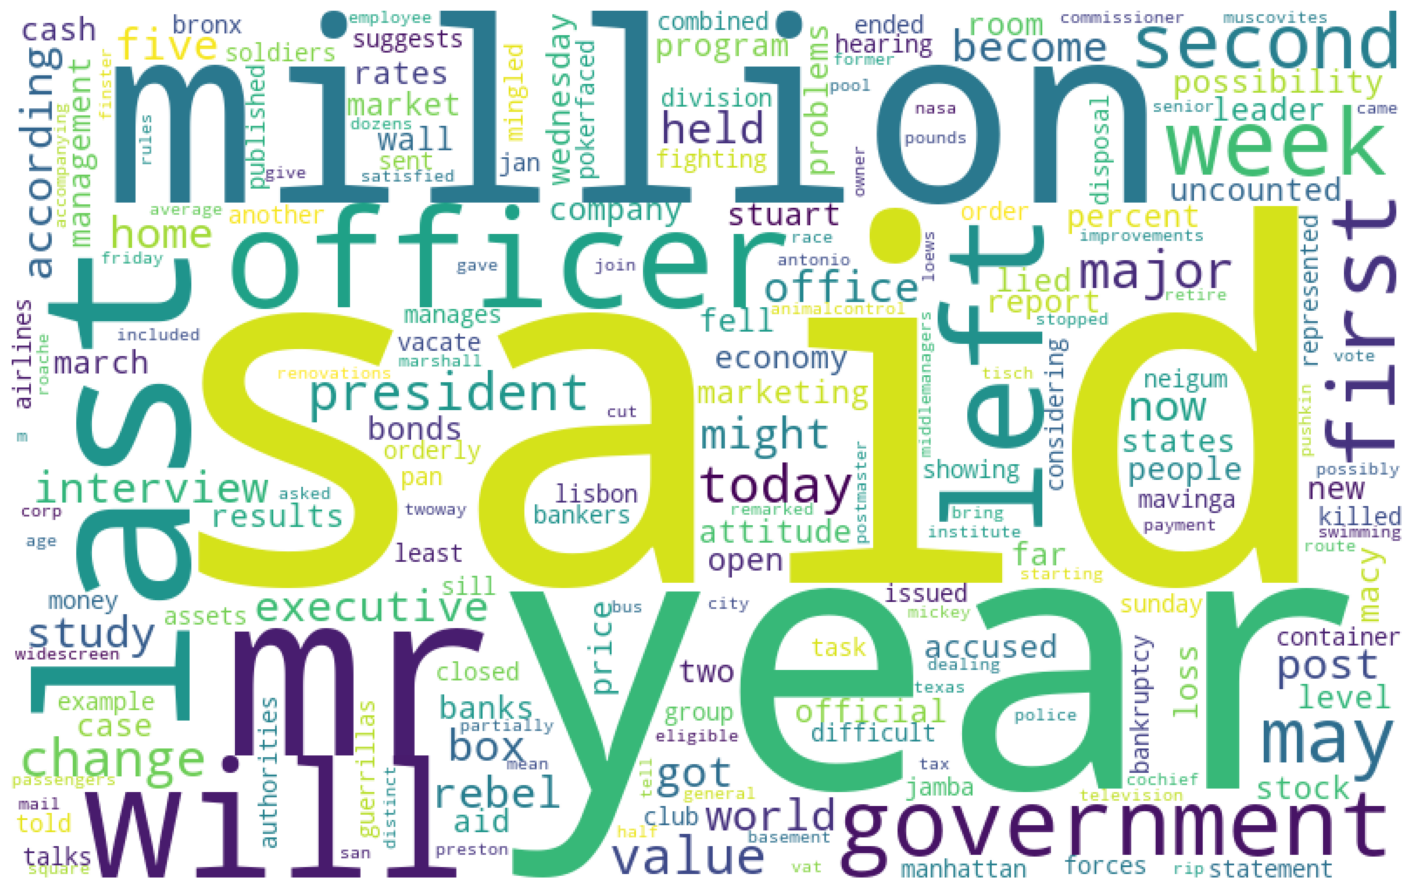

In [89]:
plt.subplots(figsize=(18,16))
word_cloud=WordCloud(width=800,height=500,background_color='white').generate(' '.join(txtWords.collect()[:1200]))
plt.imshow(word_cloud)
plt.axis('off')
plt.show


In [91]:
uniqueTxtWords = txtWords.map(lambda word: (word , 1))
uniqueTxtWords.take(20)

[('a', 1),
 ('rebel', 1),
 ('statement', 1),
 ('sent', 1),
 ('to', 1),
 ('lisbon', 1),
 ('from', 1),
 ('jamba', 1),
 ('said', 1),
 ('', 1),
 ('government', 1),
 ('soldiers', 1),
 ('and', 1),
 ('', 1),
 ('guerrillas', 1),
 ('were', 1),
 ('killed', 1),
 ('in', 1),
 ('the', 1),
 ('fighting', 1)]

In [93]:
wordCounts = uniqueTxtWords.reduceByKey(lambda x , y : x + y)
wordCounts.take(15)

[('rebel', 1068),
 ('to', 566282),
 ('', 441590),
 ('soldiers', 3388),
 ('and', 448469),
 ('guerrillas', 1947),
 ('were', 68093),
 ('it', 145795),
 ('last', 36104),
 ('closed', 6964),
 ('another', 12360),
 ('at', 116261),
 ('pan', 1153),
 ('represented', 988),
 ('neigum', 2)]

In [94]:
wordCounts.count()

207043

In [96]:
sortedWord_Counts = sorted(wordCounts.collect(), key = lambda x : x[1], reverse=True)
sortedWord_Counts = spark.sparkContext.parallelize(sortedWord_Counts)
sortedWord_Counts.take(15)

[('the', 1370263),
 ('of', 595835),
 ('to', 566282),
 ('a', 507828),
 ('in', 473567),
 ('and', 448469),
 ('', 441590),
 ('is', 400135),
 ('said', 215897),
 ('for', 214759),
 ('that', 206239),
 ('on', 155850),
 ('it', 145795),
 ('was', 142318),
 ('he', 132593)]

In [97]:
first10Words = sortedWord_Counts.take(10)


In [117]:
with open("firsttenwords.txt", 'w') as f:
    for word , count in first10Words:
        f.write(f'{word}\t{count}\n')

In [143]:
print(r"""
   __        __   _                                    
   \ \      / /__| | ___ ___  _ __ ___   ___   
    \ \ /\ / / _ \ |/ __/ _ \| '_ ` _ \ / _ \  
     \ V  V /  __/ | (_| (_) | | | | | |  __/ 
      \_/\_/ \___|_|\___\___/|_| |_| |_|\___|   
""")


print('WORD\t--\tCOUNT')
print('---------------------------------------------')

# Reading and processing the file
with open('firsttenwords.txt', 'r') as f:
    for line in f:
        line = line.strip()
        if not line:  # Skip empty lines
            continue
        parts = re.split(r'\t+', line)  # Split by one or more tabs
        if len(parts) == 2:  # Ensure we have both a word and a count
            word, count = parts
            print(f"- {word}\t\t{count}")
        else:
            print(f"- \t        { parts[-1]}")  # Handle blank spacewords



   __        __   _                                    
   \ \      / /__| | ___ ___  _ __ ___   ___   
    \ \ /\ / / _ \ |/ __/ _ \| '_ ` _ \ / _ \  
     \ V  V /  __/ | (_| (_) | | | | | |  __/ 
      \_/\_/ \___|_|\___\___/|_| |_| |_|\___|   

WORD	--	COUNT
---------------------------------------------
- the		1370263
- of		595835
- to		566282
- a		507828
- in		473567
- and		448469
- 	        441590
- is		400135
- said		215897
- for		214759


In [146]:
sparko.stop()
print(r'''
 _                
| |               
| |__  _   _  ___ 
| '_ \| | | |/ _ \
| |_) | |_| |  __/
|_.__/ \__, |\___|
        __/ |     
       |___/   ''')


 _                
| |               
| |__  _   _  ___ 
| '_ \| | | |/ _ \
| |_) | |_| |  __/
|_.__/ \__, |\___|
        __/ |     
       |___/   
